# Tutorial 12 — LangGraph Agent: ChEMBL + PubChem (OpenAI)
**Author:** Himanshu Goel | [Website](https://himanshugoel.github.io)

A drug intelligence agent built with LangGraph — structured, stateful, and real-time.

**Pipeline (4 steps):**
1. **Fetch Structure** → PubChem REST API: SMILES, formula, MW, XLogP, TPSA, HBD/HBA, Lipinski Ro5
2. **Fetch Bioactivity** → ChEMBL: hERG assay data (cardiac safety target)
3. **AI Summarize** → GPT-4o-mini: natural-language drug intelligence report
4. **Display** → Formatted box report with Ro5 compliance flags and hERG risk alerts

In [1]:
# Install all required packages
!pip install langchain langgraph langchain-openai requests python-dotenv -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import operator
import textwrap
import requests
from typing import TypedDict, Annotated

from dotenv import load_dotenv
from IPython.display import display, Image
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, END

# ── API Key ───────────────────────────────────────────────────────────────────
load_dotenv()
# os.environ["OPENAI_API_KEY"] = "sk-..."   # or set directly here

assert os.environ.get("OPENAI_API_KEY"), "OPENAI_API_KEY not found! Add it to a .env file."

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
print("✓ OpenAI LLM ready:", llm.model_name)

/Users/himanshugoel/Downloads/claudecode/computational-science-tutorials/notebooks/gnn_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ OpenAI LLM ready: gpt-4o-mini


In [3]:
# ── Input type detection ──────────────────────────────────────────────────────
# Decision: no pre-canonicalization needed — PubChem accepts any valid SMILES
# (Kekulé, aromatic, with/without stereo) and standardizes it internally.
# We just need to detect whether the user passed a name or a SMILES string.

def detect_input_type(query: str) -> str:
    """
    Heuristic: SMILES always contain bond/ring characters that never appear in
    plain drug names. We check for '=', '[', ']', '#', '@' which are unambiguous.
    Parentheses alone are NOT used as an indicator — IUPAC names also use them
    (e.g. '2-(4-isobutylphenyl)propanoic acid').
    """
    return "smiles" if any(c in query for c in "=[#@") or ("[" in query) else "name"


# ── Tool 1: PubChem profile — accepts name OR SMILES ─────────────────────────
# IMPORTANT: Do NOT include "CID" in the property list — causes PUGREST.BadRequest.
#            CID is always returned automatically by PubChem in every response.
# InChIKey is included so we can bridge to ChEMBL via an exact structural match.

PUBCHEM_PROPS = ",".join([
    "IUPACName", "MolecularFormula", "MolecularWeight", "CanonicalSMILES",
    "InChIKey",           # universal cross-database identifier (used for ChEMBL lookup)
    "XLogP", "HBondDonorCount", "HBondAcceptorCount",
    "RotatableBondCount", "TPSA", "Complexity",
])

def get_compound_profile(query: str, input_type: str = "name") -> dict:
    """
    Accepts either a compound name or a SMILES string.
    - Name   → GET  /compound/name/{name}/property/...
    - SMILES → POST /compound/smiles/property/...
      POST avoids URL-encoding issues: SMILES contain '=', '#', '[' etc.
      PubChem canonicalizes any SMILES internally — callers never need to pre-standardize.
    """
    base  = "https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound"
    props = f"/property/{PUBCHEM_PROPS}/JSON"

    if input_type == "smiles":
        r = requests.post(f"{base}/smiles{props}", data={"smiles": query}, timeout=15)
    else:
        r = requests.get(f"{base}/name/{query}{props}", timeout=10)

    if not r.ok:
        return {"error": f"PubChem lookup failed (HTTP {r.status_code}) for: {query[:60]}"}

    p = r.json()["PropertyTable"]["Properties"][0]

    mw    = float(p.get("MolecularWeight", 999))
    xlogp = float(p.get("XLogP") or 99)
    hbd   = int(p.get("HBondDonorCount", 99))
    hba   = int(p.get("HBondAcceptorCount", 99))
    ro5   = {
        "MW_ok":      mw    <= 500,
        "LogP_ok":    xlogp <= 5,
        "HBD_ok":     hbd   <= 5,
        "HBA_ok":     hba   <= 10,
        "violations": sum([mw > 500, xlogp > 5, hbd > 5, hba > 10]),
    }
    ro5["drug_like"] = ro5["violations"] <= 1

    tpsa = float(p.get("TPSA") or 0)
    tpsa_class = ("CNS-penetrant (< 60 Å²)" if tpsa < 60
                  else "Good oral absorption (< 140 Å²)" if tpsa < 140
                  else "Poor absorption (≥ 140 Å²)")

    iupac = (p.get("IUPACName") or "")[:80]
    # display_name: keep the user's input for name queries;
    # use IUPAC name for SMILES queries (raw SMILES is not human-readable in a report).
    display_name = (query if input_type == "name"
                    else iupac or query[:40] + ("…" if len(query) > 40 else ""))

    return {
        "query":        query,
        "input_type":   input_type,
        "display_name": display_name,
        "cid":          p.get("CID"),
        "formula":      p.get("MolecularFormula", ""),
        "smiles":       p.get("CanonicalSMILES", ""),
        "inchikey":     p.get("InChIKey", ""),   # bridges to ChEMBL
        "iupac":        iupac,
        "mw":   mw,   "xlogp":    xlogp, "hbd":      hbd,
        "hba":  hba,  "rotatable": p.get("RotatableBondCount"),
        "tpsa": tpsa, "tpsa_class": tpsa_class,
        "complexity": p.get("Complexity"),
        "ro5":  ro5,
    }


# ── ChEMBL bridge: InChIKey → molecule_chembl_id ─────────────────────────────
# InChIKey is a fixed-length hash of the molecular structure — exact and database-agnostic.
# This is the correct way to look up a SMILES-derived compound in ChEMBL because:
#   • molecule_pref_name requires the exact uppercase name stored in ChEMBL
#   • A novel/experimental compound entered as SMILES may have no pref_name at all
#   • molecule_chembl_id works for activity queries regardless of input modality

def get_chembl_mol_id(inchikey: str) -> tuple:
    """Returns (molecule_chembl_id, pref_name) from an InChIKey, or (None, None)."""
    url = (f"https://www.ebi.ac.uk/chembl/api/data/molecule.json"
           f"?molecule_structures__standard_inchi_key={inchikey}")
    r = requests.get(url, timeout=10)
    if r.ok:
        mols = r.json().get("molecules", [])
        if mols:
            return mols[0].get("molecule_chembl_id"), mols[0].get("pref_name")
    return None, None


# ── Tool 2: ChEMBL multi-target bioactivity ──────────────────────────────────
CHEMBL_TARGETS = [
    ("hERG",   "CHEMBL240"),   # cardiac K+ channel — most critical safety screen
    ("COX-2",  "CHEMBL230"),   # cyclooxygenase-2 — anti-inflammatory / GI toxicity
    ("CYP3A4", "CHEMBL340"),   # major drug-metabolising enzyme — drug-drug interactions
]

def get_multi_target_activities(compound_name: str, inchikey: str = "") -> dict:
    """
    Query 3 targets for the compound.
    Strategy (in order of preference):
      1. InChIKey → molecule_chembl_id  (exact structural match; works for SMILES input
         and is more reliable than string matching for name input too)
      2. Fallback → molecule_pref_name UPPERCASE  (used if InChIKey not in ChEMBL)
    """
    chembl_mol_id = None
    if inchikey:
        chembl_mol_id, _ = get_chembl_mol_id(inchikey)

    results = {}
    for target_name, chembl_id in CHEMBL_TARGETS:
        if chembl_mol_id:
            # Preferred: exact molecule ID lookup
            url = (f"https://www.ebi.ac.uk/chembl/api/data/activity.json"
                   f"?molecule_chembl_id={chembl_mol_id}"
                   f"&target_chembl_id={chembl_id}&limit=5")
        else:
            # Fallback: name-based lookup (pref_name must be uppercase in ChEMBL)
            url = (f"https://www.ebi.ac.uk/chembl/api/data/activity.json"
                   f"?molecule_pref_name={compound_name.upper()}"
                   f"&target_chembl_id={chembl_id}&limit=5")
        r = requests.get(url, timeout=10)
        results[target_name] = (
            [{"value": a.get("standard_value"), "units": a.get("standard_units"),
              "type":  a.get("standard_type"),  "assay": (a.get("assay_description") or "")[:80]}
             for a in r.json().get("activities", [])]
            if r.ok else []
        )
    return results


# ── Smoke test — name AND SMILES inputs ───────────────────────────────────────
print(f"{'Input':<8} {'Query':<44} {'Formula':<12} {'CID'}")
print("-" * 75)
test_inputs = [
    "terfenadine",                        # by name
    "CC(C)Cc1ccc(cc1)C(C)C(=O)O",        # ibuprofen by SMILES (no stereo)
    "Cn1cnc2c1c(=O)n(c(=O)n2C)C",        # caffeine by SMILES (aromatic)
    "CC(=O)Oc1ccccc1C(=O)O",             # aspirin by SMILES
]
for q in test_inputs:
    itype = detect_input_type(q)
    p     = get_compound_profile(q, itype)
    if "error" not in p:
        acts  = get_multi_target_activities(q, p.get("inchikey", ""))
        total = sum(len(v) for v in acts.values())
        print(f"{itype:<8} {q[:44]:<44} {p.get('formula'):<12} {p.get('cid')}  ChEMBL={total}")
    else:
        print(f"{itype:<8} {q[:44]:<44} ERROR: {p['error']}")

Input    Query                                        Formula      CID
---------------------------------------------------------------------------
name     terfenadine                                  C32H41NO2    5405  ChEMBL=13
smiles   CC(C)Cc1ccc(cc1)C(C)C(=O)O                   C13H18O2     3672  ChEMBL=13
smiles   Cn1cnc2c1c(=O)n(c(=O)n2C)C                   C8H10N4O2    2519  ChEMBL=14
smiles   CC(=O)Oc1ccccc1C(=O)O                        C9H8O4       2244  ChEMBL=13


## Step 2 — Agent State & Nodes

### Shared State
Every node reads and writes this dict. LangGraph merges partial returns — nodes only update the keys they own.

| Field | Type | Populated by |
|---|---|---|
| `compound` | `str` | User input |
| `structure` | `dict` | Node 1 — PubChem (11 properties + Ro5 flags) |
| `bioactivity` | `list` | Node 2 — ChEMBL hERG assay rows |
| `summary` | `str` | Node 3 — GPT-4o-mini natural language report |
| `messages` | `list` | All nodes — append-only audit log |

### Graph Architecture
```
                    ┌─────────────────┐
     Input ────────▶│ fetch_structure  │  (PubChem REST API)
                    └────────┬────────┘
                             │ structure dict
                             ▼
                    ┌─────────────────┐
                    │ fetch_bioactivity│  (ChEMBL REST API)
                    └────────┬────────┘
                             │ bioactivity list
                             ▼
                    ┌─────────────────┐
                    │    summarize     │  (OpenAI GPT-4o-mini)
                    └────────┬────────┘
                             │ summary string
                             ▼
                           [END]
```

In [4]:
# ── Shared State ─────────────────────────────────────────────────────────────
class AgentState(TypedDict):
    compound:    str    # raw user input — name or SMILES
    structure:   dict   # PubChem profile (includes input_type, display_name, inchikey)
    bioactivity: dict   # {target_name: [records]}
    summary:     str    # GPT-generated report
    messages:    Annotated[list, operator.add]


# ── Node 1: PubChem lookup (name or SMILES — auto-detected) ──────────────────
def node_fetch_structure(state: AgentState) -> dict:
    query = state["compound"]
    itype = detect_input_type(query)
    label = f"SMILES" if itype == "smiles" else f"name"
    print(f"  [Node 1] PubChem ({label}) → '{query[:50]}'")

    data = get_compound_profile(query, itype)
    if "error" in data:
        return {"structure": data, "messages": [f"[ERROR] {data['error']}"]}

    ro5 = data["ro5"]
    log = (f"[{label}] {data['display_name']} | "
           f"{data['formula']} MW={data['mw']} Da | "
           f"XLogP={data['xlogp']} | TPSA={data['tpsa']} Å² | "
           f"Ro5 violations={ro5['violations']} | InChIKey={data['inchikey'][:14]}…")
    return {"structure": data, "messages": [log]}


# ── Node 2: ChEMBL multi-target (uses InChIKey bridge when available) ─────────
def node_fetch_bioactivity(state: AgentState) -> dict:
    s        = state.get("structure", {})
    query    = state["compound"]
    inchikey = s.get("inchikey", "")
    label    = s.get("display_name", query)
    print(f"  [Node 2] ChEMBL (3 targets) → '{label}'")

    # Pass inchikey so get_multi_target_activities uses molecule_chembl_id (exact match)
    data = get_multi_target_activities(query, inchikey)

    high_risk = []
    for target, acts in data.items():
        for a in acts:
            try:
                if a.get("type") == "IC50" and float(a["value"]) < 1000:
                    high_risk.append(f"{target} IC50={a['value']} nM")
            except (TypeError, ValueError):
                pass

    total     = sum(len(v) for v in data.values())
    risk_flag = f" ⚠ {'; '.join(high_risk)}" if high_risk else ""
    log       = f"ChEMBL: {total} records / 3 targets{risk_flag}"
    return {"bioactivity": data, "messages": [log]}


# ── Node 3: GPT-4o-mini report ────────────────────────────────────────────────
def node_summarize(state: AgentState) -> dict:
    s    = state.get("structure", {})
    acts = state.get("bioactivity", {})
    ro5  = s.get("ro5", {})
    name = s.get("display_name", state["compound"])
    print(f"  [Node 3] GPT summarisation → '{name}'")

    bio_text = ""
    for target_name, records in acts.items():
        bio_text += f"\n{target_name} ({len(records)} records):\n"
        for a in records[:3]:
            bio_text += f"  {a.get('type')}: {a.get('value')} {a.get('units') or ''}\n"
        if not records:
            bio_text += "  No data.\n"

    context = f"""
Compound      : {name}
Input type    : {s.get('input_type','name')}  (InChIKey: {s.get('inchikey','N/A')})
Formula       : {s.get('formula','N/A')}  MW: {s.get('mw','N/A')} Da
XLogP         : {s.get('xlogp','N/A')}
HBD / HBA     : {s.get('hbd','N/A')} / {s.get('hba','N/A')}
TPSA          : {s.get('tpsa','N/A')} Å² — {s.get('tpsa_class','')}
Lipinski Ro5  : {ro5.get('violations','?')} violation(s) — {'PASS' if ro5.get('drug_like') else 'FAIL'}
Target Bioactivity:{bio_text}"""

    prompt = (
        "You are a senior medicinal chemist. Write a concise drug intelligence brief (≤ 180 words) covering:\n"
        "1. Chemical identity and drug class\n"
        "2. Lipinski Ro5 drug-likeness verdict\n"
        "3. hERG cardiac liability (HIGH/MODERATE/LOW risk; cite IC50 if available)\n"
        "4. COX-2 activity — anti-inflammatory potential? GI risk?\n"
        "5. CYP3A4 — metabolism liability or drug-drug interaction risk?\n"
        "6. One-sentence safety/clinical takeaway\n\n" + context
    )

    try:
        response = llm.invoke([HumanMessage(content=prompt)])
        summary  = response.content.strip()
    except Exception as e:
        summary = f"[GPT call failed: {e}]"

    return {"summary": summary, "messages": ["GPT summary complete"]}


print("✓ AgentState and 3 nodes defined")

✓ AgentState and 3 nodes defined


## Step 3 — Assemble, Compile & Visualise the Graph

`StateGraph` wires nodes into a directed execution plan. `.compile()` validates all edges.
After compiling we render the graph architecture two ways:
- **PNG image** via LangGraph's Mermaid renderer (requires internet)
- **ASCII fallback** if the renderer is unavailable

✓ Graph compiled

──────────────────────────────────────────────────
  LANGGRAPH ARCHITECTURE
──────────────────────────────────────────────────


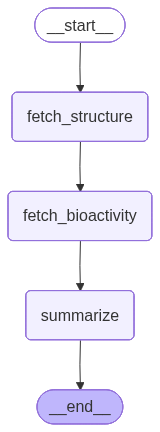

  ↑ Rendered by LangGraph (Mermaid → PNG)

  Nodes : ['fetch_structure', 'fetch_bioactivity', 'summarize']
  Edges : [('__start__', '→', 'fetch_structure'), ('fetch_bioactivity', '→', 'summarize'), ('fetch_structure', '→', 'fetch_bioactivity'), ('summarize', '→', '__end__')]


In [5]:
# ── Build the graph ───────────────────────────────────────────────────────────
graph = StateGraph(AgentState)

# Register the three nodes
graph.add_node("fetch_structure",   node_fetch_structure)
graph.add_node("fetch_bioactivity", node_fetch_bioactivity)
graph.add_node("summarize",         node_summarize)

# Entry point — LangGraph starts execution here
graph.set_entry_point("fetch_structure")

# Sequential edges: output of each node flows into the next
graph.add_edge("fetch_structure",   "fetch_bioactivity")
graph.add_edge("fetch_bioactivity", "summarize")
graph.add_edge("summarize",         END)   # END signals LangGraph to stop

# compile() validates the graph and returns an executable app
app = graph.compile()
print("✓ Graph compiled\n")

# ── Graph Architecture Visualization ─────────────────────────────────────────
# LangGraph can render its own graph as a Mermaid diagram (PNG) or ASCII art.

print("─" * 50)
print("  LANGGRAPH ARCHITECTURE")
print("─" * 50)

# Method 1: PNG render via Mermaid.ink (best quality, needs internet)
try:
    png_bytes = app.get_graph().draw_mermaid_png()
    display(Image(data=png_bytes))
    print("  ↑ Rendered by LangGraph (Mermaid → PNG)")
except Exception:
    # Method 2: ASCII fallback — always works offline
    print()
    try:
        app.get_graph().print_ascii()
    except Exception:
        # Method 3: plain Mermaid source — paste into mermaid.live to visualise
        print("  Mermaid source (paste into https://mermaid.live):\n")
        print(app.get_graph().draw_mermaid())

print()
# Print the node/edge inventory so the structure is always inspectable in text
g = app.get_graph()
print("  Nodes :", [n for n in g.nodes if n not in ("__start__", "__end__")])
print("  Edges :", [(e.source, "→", e.target) for e in g.edges])

## Step 4 — Run the Agent & Display Formatted Reports

Each compound gets a **structured box report** with five sections:
- **Chemical Identity** — formula, MW, PubChem CID, XLogP, TPSA, complexity
- **Lipinski Ro5** — per-rule pass/fail flags and drug-likeness verdict
- **TPSA Absorption** — oral / CNS-penetration classification
- **hERG Bioactivity** — IC50 values with HIGH/LOW risk flags
- **GPT-4o-mini Summary** — AI-written medicinal chemistry brief

Test compounds (chosen for contrast):

| Compound | Expected Ro5 | Expected hERG |
|---|---|---|
| **Terfenadine** | FAIL (LogP > 5) | HIGH risk — withdrawn for cardiac toxicity |
| **Ibuprofen** | PASS | LOW risk |
| **Caffeine** | PASS | LOW / no data |

In [6]:
# ── Formatted terminal report ─────────────────────────────────────────────────
def print_report(compound: str, result: dict) -> None:
    s   = result.get("structure", {})
    bio = result.get("bioactivity", {})
    ro5 = s.get("ro5", {})
    W   = 68

    display_name = s.get("display_name", compound)
    itype        = s.get("input_type", "name")
    badge        = "[SMILES]" if itype == "smiles" else "[NAME]  "

    def box_line(text="", pad=2):
        content = " " * pad + text
        if len(content) > W:
            content = content[:W - 1] + "…"
        return f"║{content:<{W}}║"

    def section(title, heavy=True):
        c, caps = ("═", "╠╣") if heavy else ("─", "╟╢")
        return [f"{caps[0]}{c*W}{caps[1]}", box_line(title)]

    def check(flag): return "✓" if flag else "✗"

    def risk_label(typ, val):
        try:
            return "  ⚠ HIGH RISK" if (typ == "IC50" and float(val) < 1000) else "  — low risk"
        except (TypeError, ValueError):
            return ""

    divider = f"╟{'─'*W}╢"

    lines = [
        f"╔{'═'*W}╗",
        f"║{('DRUG INTELLIGENCE REPORT — ' + display_name.upper()):^{W}}║",
        f"║{(badge + '  ' + compound[:W-12]):^{W}}║",
    ]

    lines += section("1.  CHEMICAL IDENTITY")
    lines += [
        divider,
        box_line(f"Formula    : {s.get('formula','N/A')}   MW : {s.get('mw','?')} Da   CID : {s.get('cid','?')}"),
        box_line(f"InChIKey   : {s.get('inchikey','N/A')}"),
        box_line(f"XLogP      : {s.get('xlogp','?')}   Complexity : {s.get('complexity','?')}"),
        box_line(f"HBD / HBA  : {s.get('hbd','?')} / {s.get('hba','?')}   Rotatable bonds : {s.get('rotatable','?')}"),
        box_line(f"TPSA       : {s.get('tpsa','?')} Å²  →  {s.get('tpsa_class','N/A')}"),
    ]
    for chunk in textwrap.wrap(f"IUPAC      : {s.get('iupac','N/A')}", W - 2):
        lines.append(box_line(chunk))

    lines += section("2.  LIPINSKI RULE OF 5")
    lines += [
        divider,
        box_line(f"MW ≤ 500  : {check(ro5.get('MW_ok'))}    "
                 f"XLogP ≤ 5 : {check(ro5.get('LogP_ok'))}    "
                 f"HBD ≤ 5   : {check(ro5.get('HBD_ok'))}    "
                 f"HBA ≤ 10  : {check(ro5.get('HBA_ok'))}"),
        box_line("Verdict    : " + (
            "✓  PASS — drug-like" if ro5.get("drug_like")
            else f"✗  FAIL — {ro5.get('violations','?')} violation(s), poor oral bioavailability")),
    ]

    total = sum(len(v) for v in bio.values())
    lines += section(f"3.  MULTI-TARGET BIOACTIVITY  (ChEMBL — {total} records / {len(bio)} targets)")
    lines.append(divider)
    for target_name, records in bio.items():
        lines.append(box_line(f"▸ {target_name}", pad=2))
        if records:
            for a in records[:3]:
                val  = a.get("value", "?")
                unit = a.get("units") or "—"
                typ  = a.get("type", "?")
                lines.append(box_line(f"{typ:<8} : {val} {unit}{risk_label(typ, val)}", pad=4))
        else:
            lines.append(box_line("No data found", pad=4))

    lines += section("4.  AI SUMMARY  (GPT-4o-mini)")
    lines.append(divider)
    for wl in textwrap.wrap(result.get("summary", ""), width=W - 4):
        lines.append(box_line(wl))

    lines += section("AGENT AUDIT LOG", heavy=False)
    for msg in result.get("messages", []):
        lines.append(box_line(f"• {msg}"))
    lines.append(f"╚{'═'*W}╝")

    print("\n".join(lines))


# ── Run the pipeline ──────────────────────────────────────────────────────────
compounds = [
    "terfenadine",                          # by name
    "CC(C)Cc1ccc(cc1)C(C)C(=O)O",          # ibuprofen by SMILES
    "Cn1cnc2c1c(=O)n(c(=O)n2C)C",          # caffeine by SMILES (aromatic notation)
]

for compound in compounds:
    print(f"\nRunning agent -> '{compound[:55]}'")
    try:
        result = app.invoke({"compound": compound, "messages": []})
        print()
        print_report(compound, result)
    except Exception as e:
        print(f"  [ERROR] Pipeline failed: {e}")
    print()


Running agent -> 'terfenadine'
  [Node 1] PubChem (name) → 'terfenadine'
  [Node 2] ChEMBL (3 targets) → 'terfenadine'
  [Node 3] GPT summarisation → 'terfenadine'

╔════════════════════════════════════════════════════════════════════╗
║               DRUG INTELLIGENCE REPORT — TERFENADINE               ║
║                       [NAME]    terfenadine                        ║
╠════════════════════════════════════════════════════════════════════╣
║  1.  CHEMICAL IDENTITY                                             ║
╟────────────────────────────────────────────────────────────────────╢
║  Formula    : C32H41NO2   MW : 471.7 Da   CID : 5405               ║
║  InChIKey   : GUGOEEXESWIERI-UHFFFAOYSA-N                          ║
║  XLogP      : 6.6   Complexity : 582                               ║
║  HBD / HBA  : 2 / 3   Rotatable bonds : 9                          ║
║  TPSA       : 43.7 Å²  →  CNS-penetrant (< 60 Å²)                  ║
║  IUPAC      : 1-(4-tert-butylphenyl)-4-[4-         

## Key Takeaways

| Concept | What we built |
|---|---|
| **OpenAI** | `ChatOpenAI(model="gpt-4o-mini", temperature=0)` — fast, cheap, deterministic |
| **Extended properties** | 11 PubChem fields per compound: identity + ADME descriptors + Ro5 |
| **Lipinski Ro5** | Per-rule evaluation computed in Python before any LLM call |
| **TPSA classification** | CNS-penetrant / oral-bioavailable / poor-absorption thresholds |
| **hERG risk flagging** | IC50 < 1 µM automatically marked HIGH RISK in both log and report |
| **Graph architecture** | Rendered inline via `draw_mermaid_png()` — always visible in the notebook |
| **Formatted report** | Box-drawing ASCII report with 5 sections — readable without a GUI |
| **Audit log** | `Annotated[list, operator.add]` gives a per-node execution trail |
